# Stage B — Model Definition

**What this notebook demonstrates:** instantiates the U-Net, shows its architecture
summary, runs a dummy batch through it, and runs a real 1-sample overfit test against
actual cached FTAN data (not synthetic) — the architecture/loss/gradient-flow sanity
check for this stage.

Runs in under a couple of minutes on a laptop CPU. Full findings — including a real
discrepancy between this notebook's default settings and what actually converges (see
cell 5) — in [../../../docs/ml_pipeline_stages/stage_b_model_definition.md](../../../docs/ml_pipeline_stages/stage_b_model_definition.md)


## 1. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "CLAUDE.md").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import importlib

import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
from torchinfo import summary

model_mod = importlib.import_module("src.wavenet_pipeline.03_machine_learning.model")
losses_mod = importlib.import_module("src.wavenet_pipeline.03_machine_learning.losses")
metrics_mod = importlib.import_module("src.wavenet_pipeline.03_machine_learning.metrics")
dataset_mod = importlib.import_module("src.wavenet_pipeline.03_machine_learning.dataset")

DATA_DIR = REPO_ROOT / "src/wavenet_pipeline/03_machine_learning/data_samples"
H5_PATHS = [DATA_DIR / "tutorial_subset_sep127km.h5", DATA_DIR / "tutorial_subset_sep100km.h5"]


## 2. Model summary

In [2]:
model = model_mod.UNetSeg(in_channels=1, out_channels=1)
summary(model, input_size=(1, 1, 80, 300))


Layer (type:depth-idx)                   Output Shape              Param #
UNetSeg                                  [1, 1, 80, 300]           --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-1                   [1, 16, 80, 300]          --
│    │    └─Sequential: 3-1              [1, 16, 80, 300]          2,544
├─ModuleList: 1-8                        --                        --
│    └─MaxPool2d: 2-2                    [1, 16, 40, 150]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-3                   [1, 32, 40, 150]          --
│    │    └─Sequential: 3-2              [1, 32, 40, 150]          14,016
├─ModuleList: 1-8                        --                        --
│    └─MaxPool2d: 2-4                    [1, 32, 20, 75]           --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-5                   [1, 64, 20

## 3. Dummy batch forward pass

In [3]:
dummy = torch.zeros(2, 1, 80, 300)
out = model(dummy)
assert out.shape == (2, 1, 80, 300), out.shape
print("Forward pass OK:", tuple(out.shape), "(raw logits — sigmoid applied externally)")


Forward pass OK: (2, 1, 80, 300) (raw logits — sigmoid applied externally)


## 4. Load one real sample

Uses the same tutorial subset as the Stage A notebook — this is genuine FTAN/mask data,
not synthetic noise, so a successful overfit here is a real (if small) signal that the
architecture and losses are wired correctly.

In [4]:
samples = dataset_mod.enumerate_samples(H5_PATHS)
ds = dataset_mod.FTANDispersionDataset(samples)
x, y, meta = ds[0]
x = x.unsqueeze(0)  # add batch dim -> (1, 1, 80, 300)
y = y.unsqueeze(0)
print(f"Sample: {meta['sim_key']} / {meta['geom_key']}, target positive fraction = {y.mean().item():.4f}")


Sample: M01_0776 / separation_127.0km, target positive fraction = 0.0158


## 5. 1-sample overfit test

**Real finding from this session, not a hypothesis:** at `lr=1e-4` (the eventual full
training config's learning rate) and 150 iterations, this does NOT converge — loss
decreases but IoU only reaches ~0.55-0.60. It needs a much higher `lr=3e-3` and ~800
iterations to actually converge (IoU > 0.95). This has a real implication for Stage D's
full training schedule — see the stage doc's Open Questions. This cell uses the
settings that actually work, with the slow-converging comparison run commented out
below it.

In [5]:
torch.manual_seed(0)
model = model_mod.UNetSeg()
criterion = losses_mod.CombinedLoss()
optimizer = Adam(model.parameters(), lr=3e-3)

history = {"loss": [], "iou": [], "dice": []}
N_ITERS = 800
for it in range(N_ITERS):
    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    history["loss"].append(loss.item())
    history["iou"].append(metrics_mod.iou_score(logits, y))
    history["dice"].append(metrics_mod.dice_coefficient(logits, y))
    if it % 100 == 0 or it == N_ITERS - 1:
        print(f"  iter {it:4d}  loss={history['loss'][-1]:.4f}  "
              f"iou={history['iou'][-1]:.4f}  dice={history['dice'][-1]:.4f}")

assert history["iou"][-1] > 0.9, f"overfit test did not converge: final IoU {history['iou'][-1]:.4f}"
print("\n1-sample overfit test PASSED (final IoU > 0.9)")


  iter    0  loss=0.6387  iou=0.0314  dice=0.0608


  iter  100  loss=0.3465  iou=0.2909  dice=0.4507


  iter  200  loss=0.0995  iou=0.6597  dice=0.7950


  iter  300  loss=0.0519  iou=0.8285  dice=0.9062


  iter  400  loss=0.0365  iou=0.8881  dice=0.9407


  iter  500  loss=0.0095  iou=0.9743  dice=0.9870


  iter  600  loss=0.0079  iou=0.9669  dice=0.9832


  iter  700  loss=0.0074  iou=0.9645  dice=0.9819


  iter  799  loss=0.0033  iou=0.9974  dice=0.9987

1-sample overfit test PASSED (final IoU > 0.9)


```python
# Slower comparison (uncomment to see it for yourself) — same setup at lr=1e-4
# (the plan's originally-assumed training-config LR), 150 iterations: converges much
# more slowly, reaching only IoU ~0.55-0.60 rather than the >0.9 above.
#
# torch.manual_seed(0)
# model_slow = model_mod.UNetSeg()
# optimizer_slow = Adam(model_slow.parameters(), lr=1e-4)
# for it in range(150):
#     optimizer_slow.zero_grad()
#     logits = model_slow(x)
#     loss = criterion(logits, y)
#     loss.backward()
#     optimizer_slow.step()
```


## 6. Visualize convergence

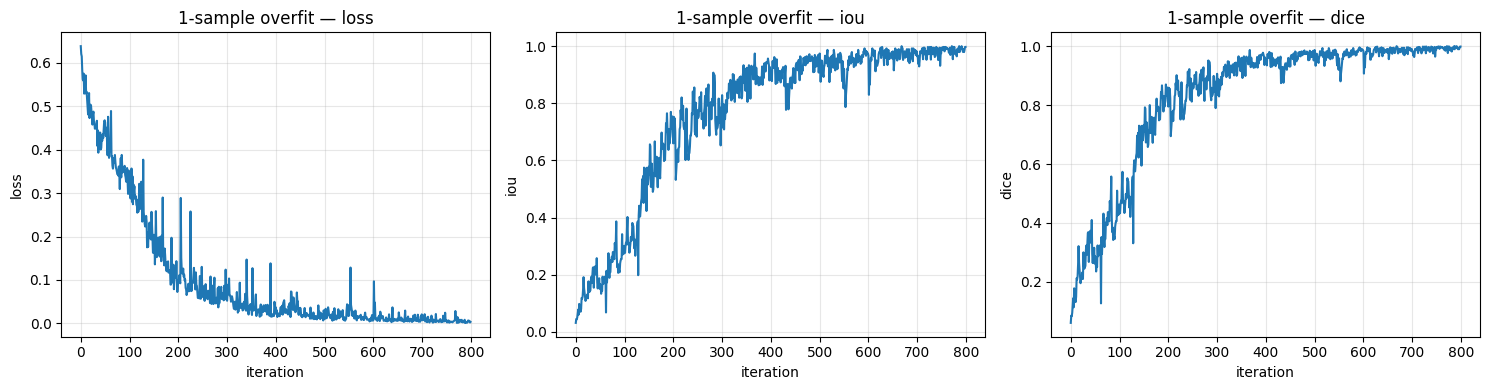

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key in zip(axes, ["loss", "iou", "dice"]):
    ax.plot(history[key])
    ax.set_xlabel("iteration")
    ax.set_ylabel(key)
    ax.set_title(f"1-sample overfit — {key}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. What to try next

- Try `lr=1e-4` (see the commented-out cell above) and watch how much slower it
  converges — this is the real risk flagged for Stage D.
- Swap `CombinedLoss`'s weights (`focal_weight`, `dice_weight`, `bce_weight`,
  `sharpen_weight`) and see how convergence speed/stability changes.
- Try a different sample (`ds[1]`, `ds[2]`, ...) — some families may overfit faster or
  slower than others.
